# Customer Churn Prediction Lab Project

**Domain:** Business / Marketing / Supply Chain  
**Problem type:** supervised binary classification  
**Goal:** predict whether a customer is likely to churn, then compare Random Forest, Logistic Regression, and SVM under the same preprocessing and test split.

This notebook follows the lab guideline requirements: problem definition, dataset preparation, preprocessing, model tuning, evaluation, model selection, and inference on unseen examples.

## 1. Problem Definition

Customer churn means losing a customer. In a business or marketing setting, predicting churn helps the company decide which customers may need retention actions such as support follow-up, discounts, or contract renewal campaigns.

The target variable is `Churn`: `1` means the customer churned and `0` means the customer stayed. Because missing churners can be expensive, we evaluate more than accuracy. Precision, recall, F1-score, and ROC-AUC are used together.

In [ ]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC

RANDOM_STATE = 42
SAMPLE_SIZE = 25000
DATA_PATH = Path(r"C:\Users\Mega-PC\Downloads\customer_churn_dataset-training-master.csv\customer_churn_dataset-training-master.csv")
OUTPUT_DIR = Path("outputs")
FIG_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

## 2. Dataset Loading and First Look

In [2]:
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.dropna().copy()
df["Churn"] = df["Churn"].astype(int)
df["CustomerID"] = df["CustomerID"].astype(int)

print("Raw shape:", df_raw.shape)
print("Clean shape after dropping the single incomplete row:", df.shape)
print("Columns:", list(df.columns))
display(df.head())

Raw shape: (440833, 12)
Clean shape after dropping the single incomplete row: (440832, 12)
Columns: ['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']


CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
2,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1
3,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1
4,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1
5,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1
6,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1


## 3. Exploratory Data Analysis

The dataset contains customer demographics, usage behavior, support interactions, payment delay, subscription information, contract length, spending, and recency of interaction. These features are directly useful for churn prediction because they describe both customer value and customer friction.

Churn,Percentage
1,56.71
0,43.29


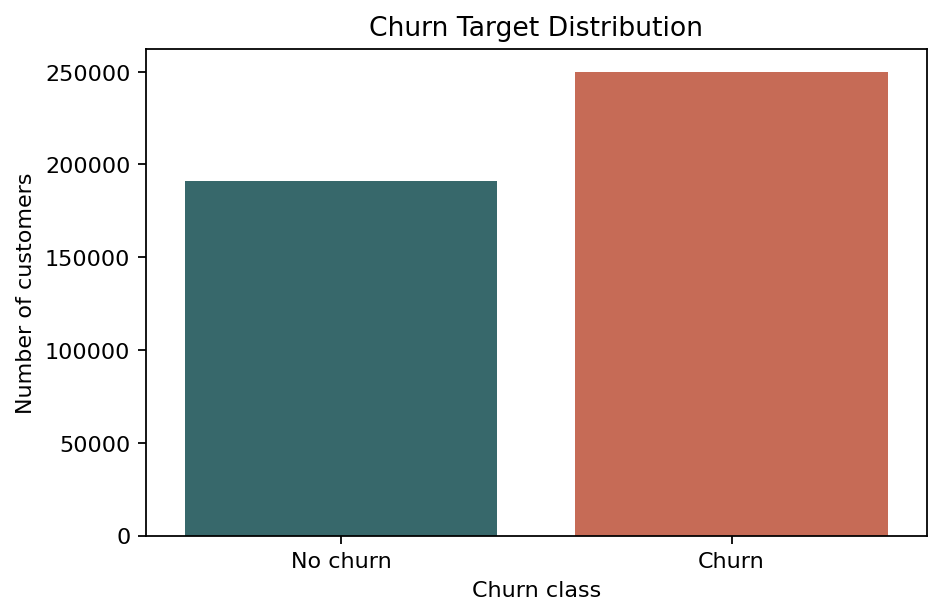

In [3]:
target_summary = (
    df["Churn"].value_counts(normalize=True)
    .rename_axis("Churn")
    .reset_index(name="Percentage")
)
target_summary["Percentage"] = (target_summary["Percentage"] * 100).round(2)
display(target_summary)

sns.countplot(data=df, x="Churn", hue="Churn", palette=["#2f6f73", "#d95f43"], legend=False)
plt.title("Churn Target Distribution")
plt.xlabel("Churn class")
plt.ylabel("Number of customers")
plt.xticks([0, 1], ["No churn", "Churn"])
plt.show()

## 4. Preprocessing and Data Split

The same preprocessing is used for all models to keep the comparison fair. Numeric features are median-imputed and scaled. Categorical features are mode-imputed and one-hot encoded. `CustomerID` is removed because it is an identifier, not a real behavioral predictor.

The dataset is very large, so this notebook uses a stratified sample for modeling. This keeps the class balance similar to the full dataset and makes the SVM practical to rerun during presentation.

In [4]:
feature_columns = [c for c in df.columns if c not in ["CustomerID", "Churn"]]
numeric_features = df[feature_columns].select_dtypes(include=np.number).columns.tolist()
categorical_features = [c for c in feature_columns if c not in numeric_features]

_, sample_df = train_test_split(
    df,
    test_size=SAMPLE_SIZE,
    stratify=df["Churn"],
    random_state=RANDOM_STATE,
)

X = sample_df[feature_columns]
y = sample_df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print("Modeling sample size:", sample_df.shape)
print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Modeling sample size: (25000, 12)
Training size: (20000, 10)
Testing size: (5000, 10)
Numeric features: ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']
Categorical features: ['Gender', 'Subscription Type', 'Contract Length']


## 5. Models and Hyperparameter Tuning

- **Random Forest:** an ensemble of decision trees. It captures non-linear patterns and is easy to explain with feature importance.
- **Logistic Regression:** a simple linear classifier. It estimates churn probability with a weighted sum of the input features and is easy to explain.
- **SVM:** a linear support vector machine. It searches for a separating boundary with a maximum margin. Probability calibration is added so ROC-AUC can be compared fairly.

Grid search uses cross-validation and F1-score because churn prediction needs a balance between finding churners and avoiding too many false alarms.

In [5]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False)),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

model_specs = {
    "Random Forest": (
        Pipeline([
            ("preprocess", preprocessor),
            ("classifier", RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced", n_jobs=-1)),
        ]),
        {"classifier__n_estimators": [150], "classifier__max_depth": [8, None]},
    ),
    "Logistic Regression": (
        Pipeline([
            ("preprocess", preprocessor),
            ("classifier", LogisticRegression(random_state=RANDOM_STATE, class_weight="balanced", max_iter=2000, solver="liblinear")),
        ]),
        {"classifier__C": [0.1, 1.0, 10.0]},
    ),
    "SVM": (
        Pipeline([
            ("preprocess", preprocessor),
            ("classifier", CalibratedClassifierCV(estimator=LinearSVC(random_state=RANDOM_STATE, class_weight="balanced", dual="auto", max_iter=5000), method="sigmoid", cv=3)),
        ]),
        {"classifier__estimator__C": [0.1, 1.0]},
    ),
}

fitted_models = {}
tuning_rows = []
for model_name, (pipeline, param_grid) in model_specs.items():
    grid = GridSearchCV(pipeline, param_grid, scoring="f1", cv=3, n_jobs=1, refit=True)
    grid.fit(X_train, y_train)
    fitted_models[model_name] = grid.best_estimator_
    tuning_rows.append({
        "Model": model_name,
        "Best CV F1": round(float(grid.best_score_), 4),
        "Best parameters": grid.best_params_,
    })

tuning_df = pd.DataFrame(tuning_rows)
display(tuning_df)

Model,Best CV F1,Best parameters
Random Forest,0.9922,"{""classifier__max_depth"": null, ""classifier__n_estimators"": 150}"
Logistic Regression,0.9027,"{""classifier__C"": 10.0}"
SVM,0.9014,"{""classifier__estimator__C"": 1.0}"


## 6. Evaluation and Scientific Comparison

All models are evaluated on the same unseen test set. The final selection is based mainly on F1-score, while ROC-AUC shows how well each model separates churners from non-churners across thresholds.

In [6]:
metric_rows = []
roc_rows = []
confusion_rows = []

for model_name, model in fitted_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metric_rows.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })

    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_rows.extend({"Model": model_name, "FPR": f, "TPR": t, "Threshold": th} for f, t, th in zip(fpr, tpr, thresholds))

    matrix = confusion_matrix(y_test, y_pred)
    for actual_idx, actual_label in enumerate(["No churn", "Churn"]):
        for pred_idx, pred_label in enumerate(["No churn", "Churn"]):
            confusion_rows.append({
                "Model": model_name,
                "Actual": actual_label,
                "Predicted": pred_label,
                "Count": int(matrix[actual_idx, pred_idx]),
            })

metrics_df = pd.DataFrame(metric_rows).sort_values("F1", ascending=False)
roc_df = pd.DataFrame(roc_rows)
confusion_df = pd.DataFrame(confusion_rows)
metrics_rounded = metrics_df.copy()
for col in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]:
    metrics_rounded[col] = metrics_rounded[col].round(4)

display(metrics_rounded)

Model,Accuracy,Precision,Recall,F1,ROC-AUC
Random Forest,0.9902,0.9986,0.9841,0.9913,0.9999
SVM,0.8922,0.9262,0.8801,0.9025,0.9566
Logistic Regression,0.8920,0.9419,0.8628,0.9006,0.9566


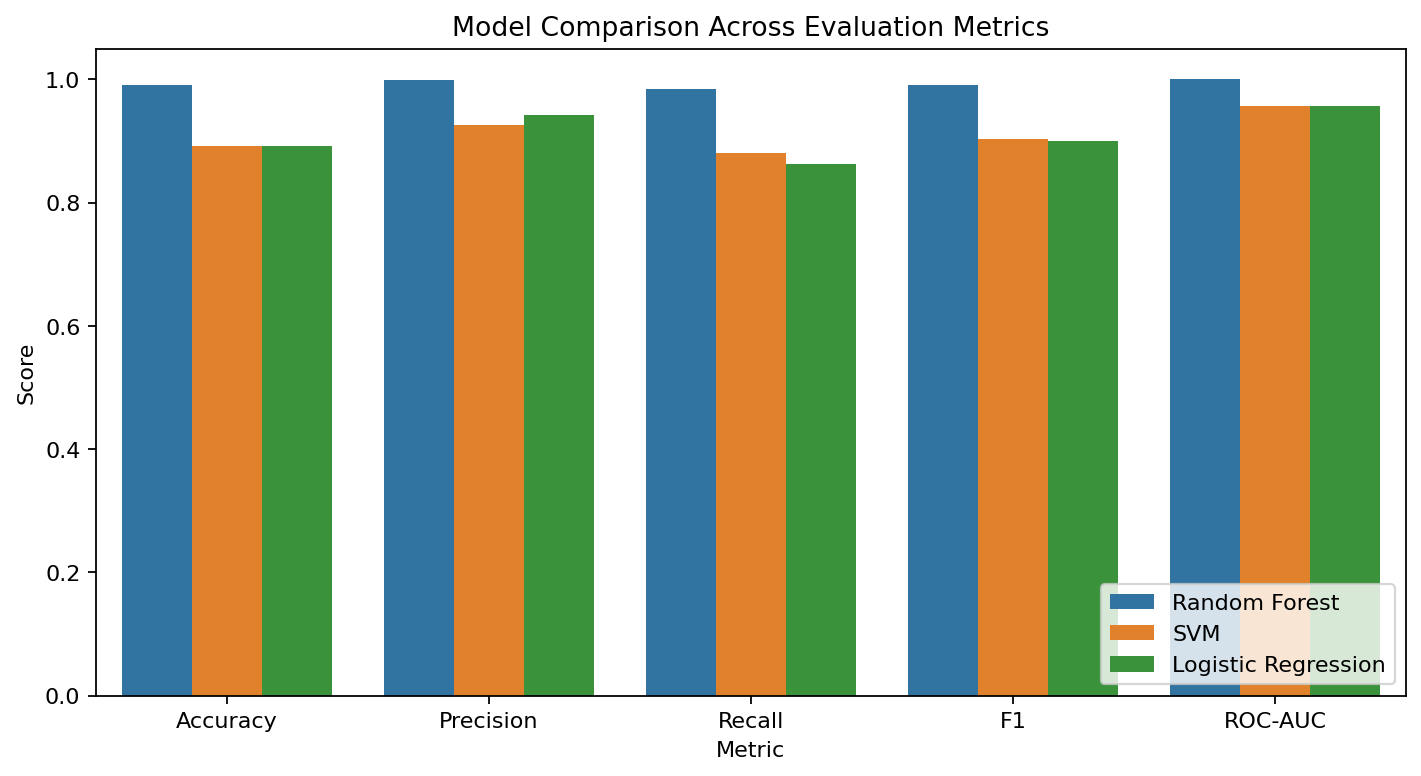

In [7]:
metric_long = metrics_rounded.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    var_name="Metric",
    value_name="Score",
)
sns.barplot(data=metric_long, x="Metric", y="Score", hue="Model")
plt.ylim(0, 1.05)
plt.title("Model Comparison Across Evaluation Metrics")
plt.legend(loc="lower right")
plt.show()

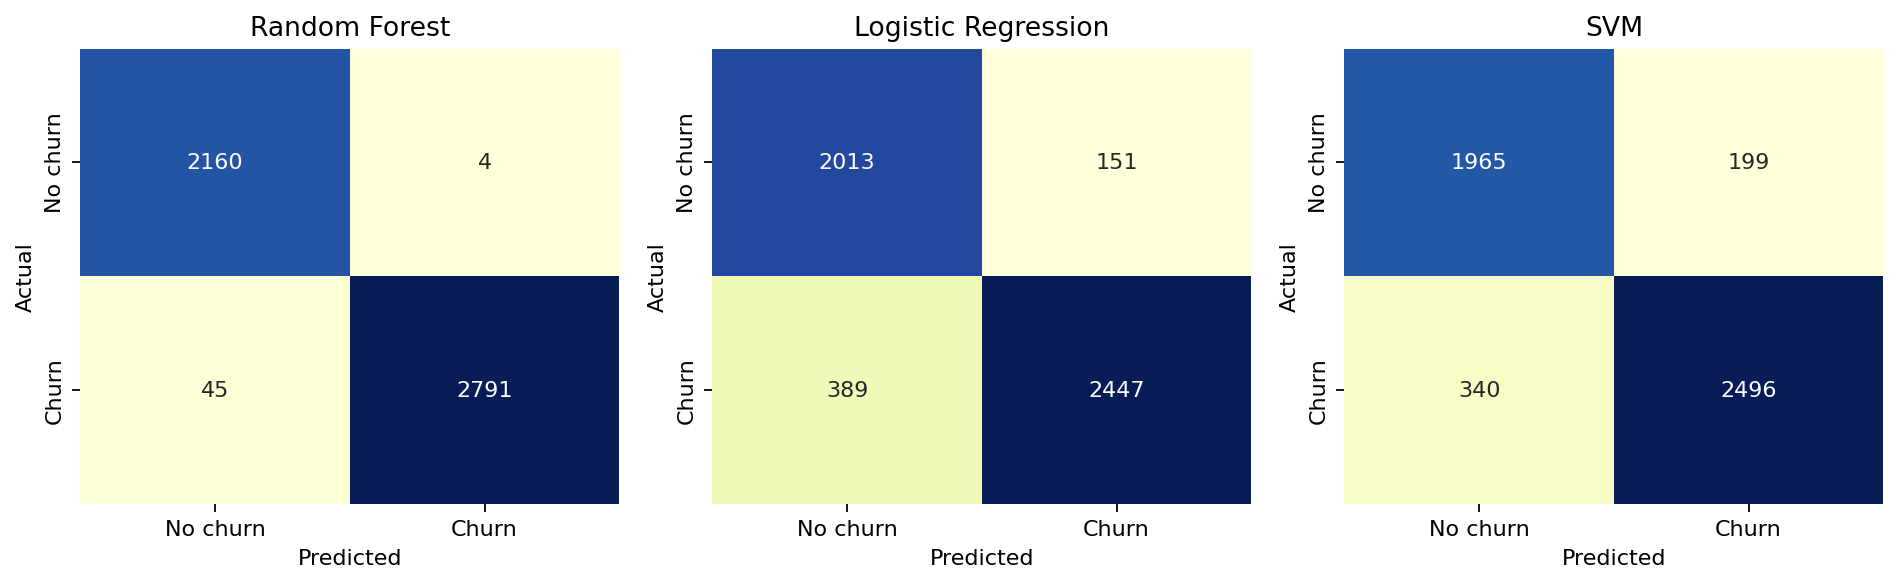

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for axis, model_name in zip(axes, fitted_models.keys()):
    sub = confusion_df[confusion_df["Model"] == model_name]
    matrix = sub.pivot(index="Actual", columns="Predicted", values="Count").loc[
        ["No churn", "Churn"], ["No churn", "Churn"]
    ]
    sns.heatmap(matrix, annot=True, fmt="d", cmap="YlGnBu", cbar=False, ax=axis)
    axis.set_title(model_name)
plt.show()

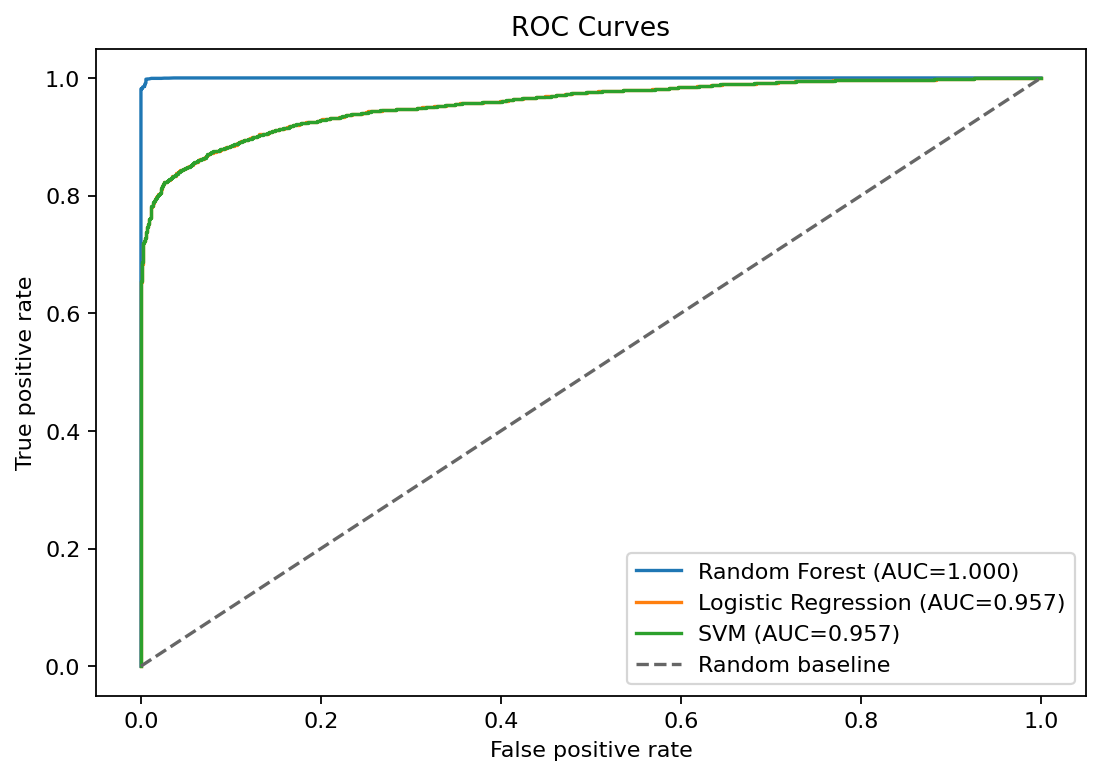

In [9]:
for model_name in fitted_models.keys():
    sub = roc_df[roc_df["Model"] == model_name]
    auc_value = metrics_rounded.loc[metrics_rounded["Model"] == model_name, "ROC-AUC"].iloc[0]
    plt.plot(sub["FPR"], sub["TPR"], label=f"{model_name} (AUC={auc_value:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="#666666", label="Random baseline")
plt.title("ROC Curves")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
plt.show()

## 7. Model Selection

Based on the test-set F1-score, the selected model is **Random Forest**. This model gives the best balance between catching churn customers and keeping false alarms controlled.

In [10]:
best_model_name = metrics_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]
print("Selected model:", best_model_name)
display(metrics_rounded[metrics_rounded["Model"] == best_model_name])

Selected model: Random Forest


Model,Accuracy,Precision,Recall,F1,ROC-AUC
Random Forest,0.9902,0.9986,0.9841,0.9913,0.9999


Feature,Importance
Support Calls,0.291643
Total Spend,0.210637
Payment Delay,0.127661
Age,0.125954
Contract Length Monthly,0.102720
Last Interaction,0.047562
Contract Length Annual,0.021516
Gender Female,0.017851
Contract Length Quarterly,0.016893
Gender Male,0.016577


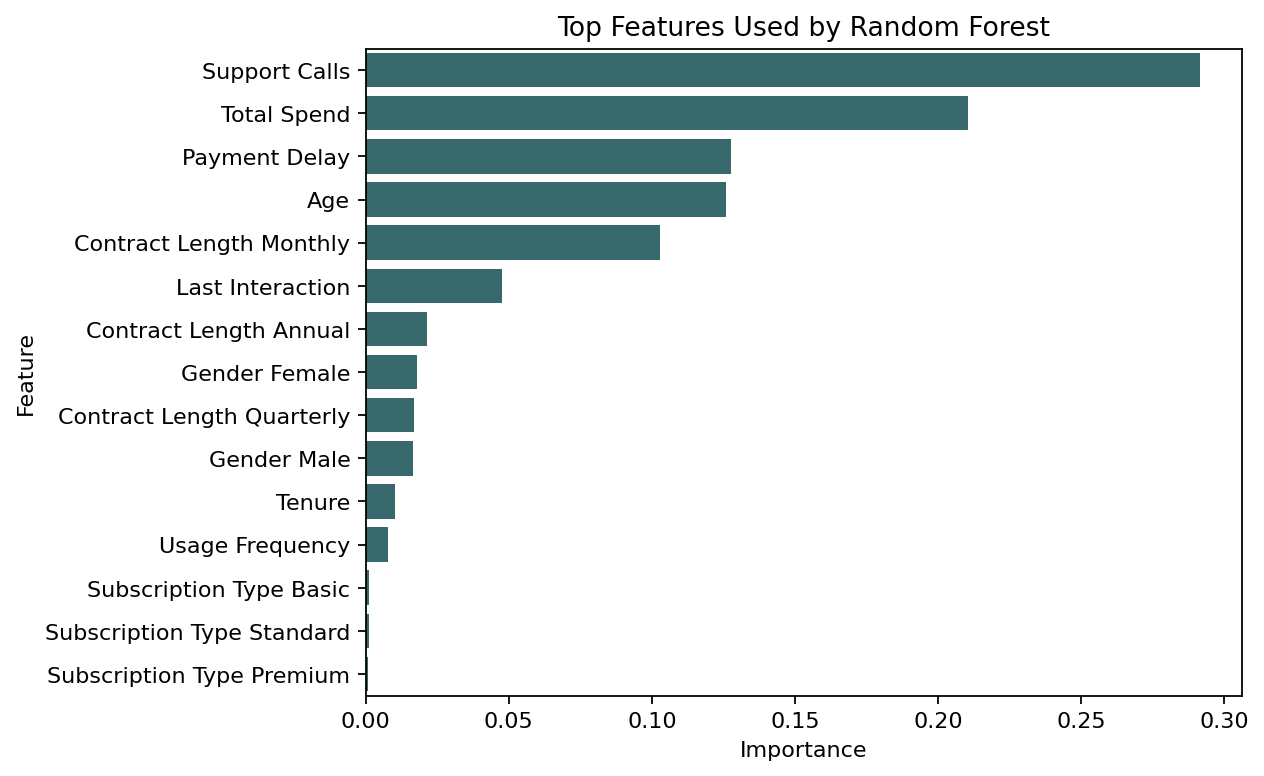

In [11]:
def clean_feature_name(name):
    return name.replace("num__", "").replace("cat__", "").replace("remainder__", "").replace("_", " ")

feature_names = [clean_feature_name(name) for name in best_model.named_steps["preprocess"].get_feature_names_out()]
classifier = best_model.named_steps["classifier"]
if hasattr(classifier, "feature_importances_"):
    importance_values = classifier.feature_importances_
elif hasattr(classifier, "coef_"):
    importance_values = np.abs(classifier.coef_).ravel()
else:
    coefs = [
        calibrated.estimator.coef_.ravel()
        for calibrated in getattr(classifier, "calibrated_classifiers_", [])
        if hasattr(calibrated.estimator, "coef_")
    ]
    importance_values = np.mean(np.abs(coefs), axis=0) if coefs else np.zeros(len(feature_names))

importance_df = (
    pd.DataFrame({"Feature": feature_names, "Importance": importance_values})
    .sort_values("Importance", ascending=False)
    .head(15)
)
display(importance_df)
sns.barplot(data=importance_df, x="Importance", y="Feature", color="#2f6f73")
plt.title(f"Top Features Used by {best_model_name}")
plt.show()

## 8. Inference on Unseen Examples

The cells below simulate how the chosen model would be used after training. We take unseen test-set customers, predict the churn class, and report the churn probability.

In [12]:
prediction_examples = X_test.head(8).copy()
prediction_examples.insert(0, "Actual Churn", y_test.head(8).to_numpy())
prediction_examples["Predicted Churn"] = best_model.predict(X_test.head(8))
prediction_examples["Churn Probability"] = best_model.predict_proba(X_test.head(8))[:, 1]
display(prediction_examples)

Actual Churn,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Predicted Churn,Churn Probability
0,46.0,Female,35.0,16.0,3.0,20.0,Premium,Quarterly,878.64,2.0,0,0.033333
1,28.0,Male,2.0,14.0,4.0,9.0,Basic,Annual,438.00,1.0,1,0.993333
0,23.0,Female,59.0,1.0,2.0,20.0,Basic,Annual,959.99,1.0,0,0.113333
1,22.0,Male,26.0,14.0,7.0,29.0,Premium,Quarterly,902.00,18.0,1,0.993333
1,20.0,Male,7.0,29.0,6.0,18.0,Standard,Quarterly,491.00,7.0,1,0.993333
1,32.0,Male,43.0,2.0,0.0,12.0,Premium,Quarterly,138.00,5.0,1,0.986667
1,19.0,Male,15.0,29.0,7.0,20.0,Basic,Quarterly,576.00,27.0,1,0.960000
0,35.0,Female,7.0,6.0,3.0,12.0,Standard,Quarterly,685.01,11.0,0,0.060000


## 9. Conclusion

This project built a complete machine learning pipeline for customer churn prediction. Random Forest, Logistic Regression, and SVM were trained with the same preprocessing and evaluated on the same unseen test data. The selected model can now be used in the Streamlit dashboard for result exploration and single-customer inference.

In [13]:
metrics_rounded.to_csv(OUTPUT_DIR / "model_metrics.csv", index=False)
tuning_df.to_csv(OUTPUT_DIR / "tuning_summary.csv", index=False)
roc_df.to_csv(OUTPUT_DIR / "roc_curves.csv", index=False)
confusion_df.to_csv(OUTPUT_DIR / "confusion_matrices.csv", index=False)
importance_df.to_csv(OUTPUT_DIR / "feature_importance.csv", index=False)
prediction_examples.to_csv(OUTPUT_DIR / "sample_predictions.csv", index=False)
joblib.dump(best_model, OUTPUT_DIR / "best_churn_model.joblib")
print("Saved dashboard artifacts in:", OUTPUT_DIR.resolve())

Saved dashboard artifacts in: C:\Users\Mega-PC\Documents\New project\outputs
